In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


**PART : 0 (DUMMY SUBMISSION)**

In [2]:
# data = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')

# data.head()
# data.tail()

# data['audience_count'].mean()

# ss = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')


# ss.head()

# ss.tail()

# ss['audience_count'] = 41

# ss.head()

# ss.to_csv('submission.csv' , index = False)

In [3]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print(" Cinema Audience Forecasting Project")
print("=" * 70)

# =============================================================================
# PART 1: LOADING THE DATA
# =============================================================================
print("\nPART 1: Loading All Datasets")
print("=" * 70)

# Load all 5 CSV files
visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
dates = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
submission_file = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')
booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
cinepos = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
cine_pos_theater = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')

print("✅ All files loaded successfully!")
print(f"Visits data shape: {visits.shape}")
print(f"Theaters data shape: {theaters.shape}")
print(f"Dates data shape: {dates.shape}")
print(f"Booking data shape: {booking.shape}")

print(f"Cinepos data shape: {cinepos.shape}")
print(f"cine_pos_theater: {cine_pos_theater.shape}")

# Convert date columns to proper datetime format
visits['show_date'] = pd.to_datetime(visits['show_date'])
dates['show_date'] = pd.to_datetime(dates['show_date'])
booking['show_datetime'] = pd.to_datetime(booking['show_datetime'])
booking['booking_datetime'] = pd.to_datetime(booking['booking_datetime'])

# Display basic information
print(f"\nTotal records: {len(visits)}")
print(f"Number of theaters: {visits['book_theater_id'].nunique()}")
print(f"Average audience: {visits['audience_count'].mean():.2f}")


 Cinema Audience Forecasting Project

PART 1: Loading All Datasets
✅ All files loaded successfully!
Visits data shape: (214046, 3)
Theaters data shape: (829, 5)
Dates data shape: (547, 2)
Booking data shape: (68336, 4)
Cinepos data shape: (1641966, 4)
cine_pos_theater: (4690, 5)

Total records: 214046
Number of theaters: 826
Average audience: 41.62


# 🎬 Cinema Audience Forecasting Project

## Part 1: Loading the Data

In this part, we load all the necessary datasets required for the cinema audience forecasting task. The data includes:

* **Visits Data:** Records of audience count per show per theater.
* **Theaters Data:** Details about different theaters.
* **Dates Data:** Information about show dates, such as day of the week.
* **Booking Data:** Records of bookings and tickets.
* **Submission Template:** Template for creating submission predictions.

We also perform the following preprocessing steps:

* Convert date columns to proper `datetime` format.
* Display basic information about the datasets:

  * Total number of records
  * Number of unique theaters
  * Average audience per show



PART 2: Exploratory Data Analysis


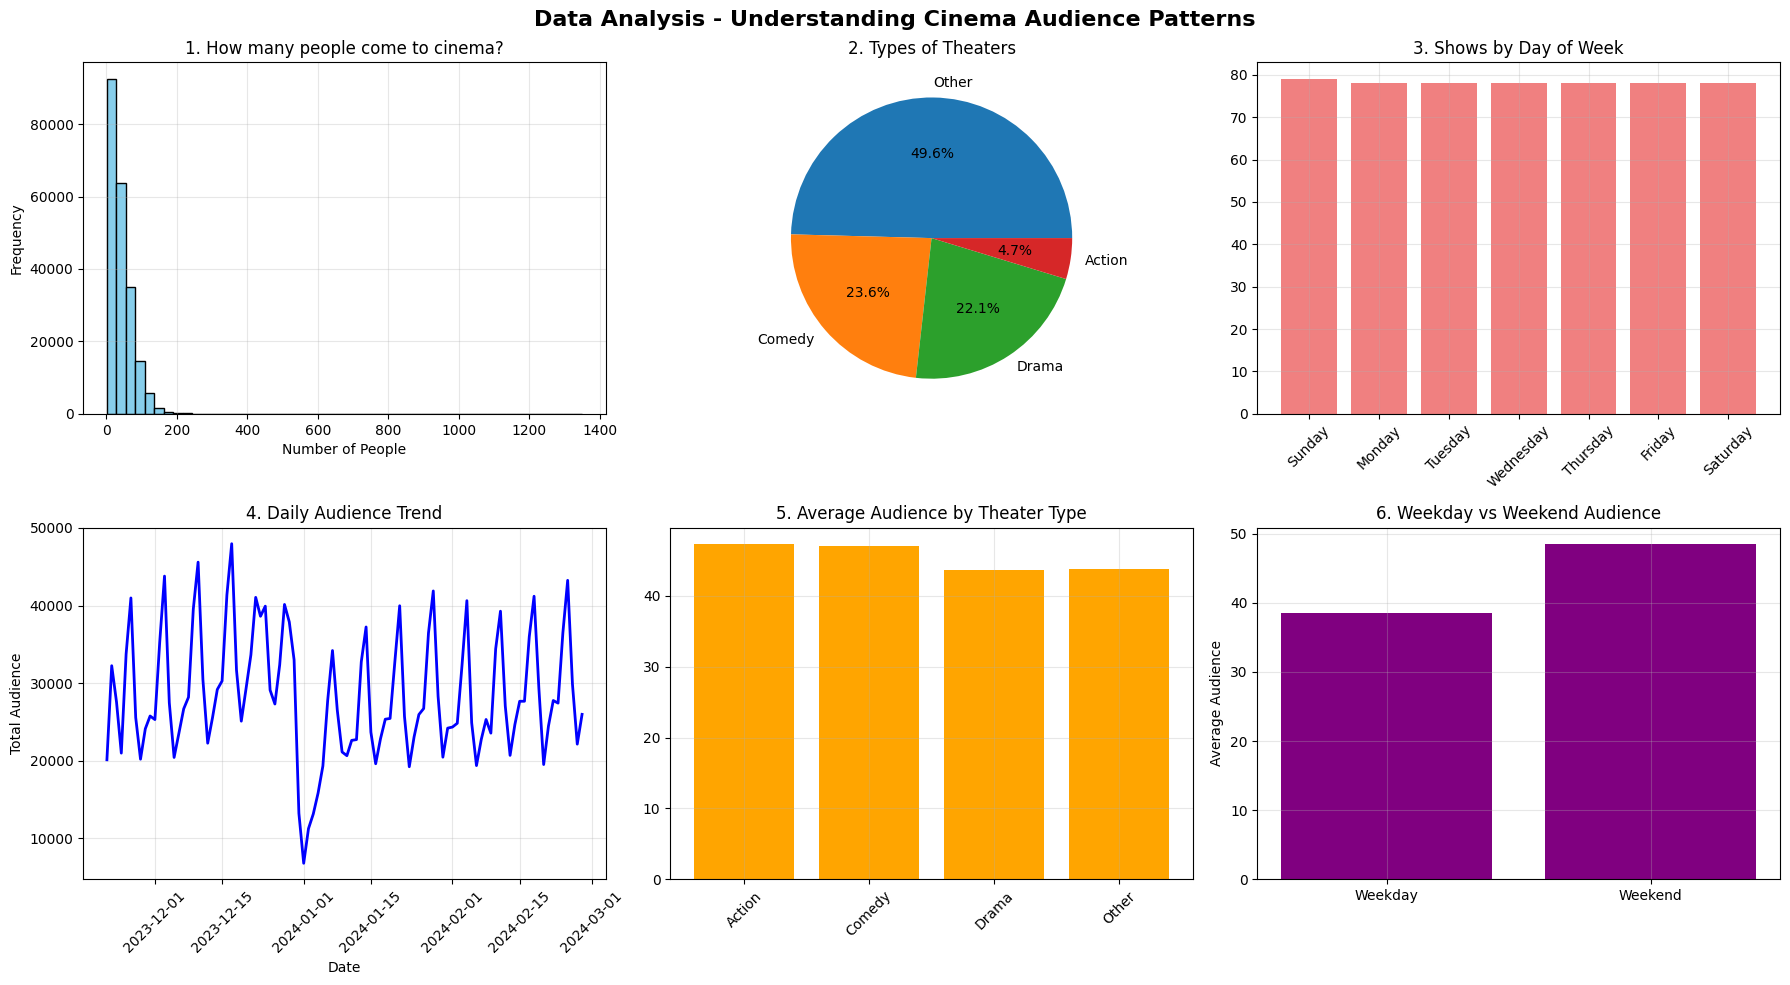

✅ EDA completed!


In [4]:
# =============================================================================
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
print("\nPART 2: Exploratory Data Analysis")
print("=" * 70)

# Create 6 visualizations to understand the data
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Data Analysis - Understanding Cinema Audience Patterns', fontsize=16, fontweight='bold')

# Plot 1: Distribution of audience count
axes[0, 0].hist(visits['audience_count'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('1. How many people come to cinema?')
axes[0, 0].set_xlabel('Number of People')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Types of theaters
theater_counts = theaters['theater_type'].value_counts()
axes[0, 1].pie(theater_counts.values, labels=theater_counts.index, autopct='%1.1f%%')
axes[0, 1].set_title('2. Types of Theaters')

# Plot 3: Which day has more shows?
day_names = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_counts = dates['day_of_week'].value_counts().reindex(day_names)
axes[0, 2].bar(day_counts.index, day_counts.values, color='lightcoral')
axes[0, 2].set_title('3. Shows by Day of Week')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Trend over time (last 100 days)
daily_total = visits.groupby('show_date')['audience_count'].sum().tail(100)
axes[1, 0].plot(daily_total.index, daily_total.values, color='blue', linewidth=2)
axes[1, 0].set_title('4. Daily Audience Trend')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Total Audience')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Average audience by theater type
data_with_theater = visits.merge(theaters, on='book_theater_id')
avg_by_theater = data_with_theater.groupby('theater_type')['audience_count'].mean()
axes[1, 1].bar(avg_by_theater.index, avg_by_theater.values, color='orange')
axes[1, 1].set_title('5. Average Audience by Theater Type')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Weekend vs Weekday comparison
visits['is_weekend'] = visits['show_date'].dt.dayofweek >= 5
weekend_avg = visits.groupby('is_weekend')['audience_count'].mean()
axes[1, 2].bar(['Weekday', 'Weekend'], weekend_avg.values, color='purple')
axes[1, 2].set_title('6. Weekday vs Weekend Audience')
axes[1, 2].set_ylabel('Average Audience')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA completed!")

## Part 2: Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the cinema audience patterns and trends. A total of **6 visualizations** are created to gain insights:

1. **Distribution of Audience Count:** Shows how many people typically attend a cinema.
2. **Types of Theaters:** Pie chart showing the proportion of different theater types.
3. **Shows by Day of Week:** Bar chart showing which days have more shows scheduled.
4. **Daily Audience Trend:** Line plot showing total audience over the last 100 days.
5. **Average Audience by Theater Type:** Bar chart comparing average audience across theater types.
6. **Weekday vs Weekend Comparison:** Comparison of average audience between weekdays and weekends.

These visualizations help identify trends, patterns, and potential factors affecting audience numbers.
